In [1]:
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import numpy as np
import xarray as xr
import cmocean
from mpl_toolkits.basemap import Basemap
from matplotlib import colors

file_id = Dataset('../../data/chl/climate_slope/chla_stl_slope_20250326.nc')
ras = file_id.variables["CHL"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

pvals = ras[1,:,:]
slopes = ras[0,:,:]
sig_slopes = slopes.copy()
sig_mask = pvals > 0.05
sig_slopes[sig_mask] = 0


In [2]:
sig_slopes = xr.DataArray(sig_slopes,
    coords={'x': lat, 'y': lon},
    dims=["x", "y"])
sig_slopes.data = sig_slopes.data * 365
sig_slopes = sig_slopes.clip(min=-0.0021, max=0.0021, keep_attrs=False)

divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(sig_slopes.data), vcenter=0, vmax=np.nanmax(sig_slopes.data))


/tmp/ipykernel_3630406/388805760.py:17: UserWarning: The following kwargs were not used by contour: 'linestyle'
  m.contour(x, y, sig_binary, levels=[0.5], colors='grey', linewidths=0.2, linestyle = "-", ax=ax1)


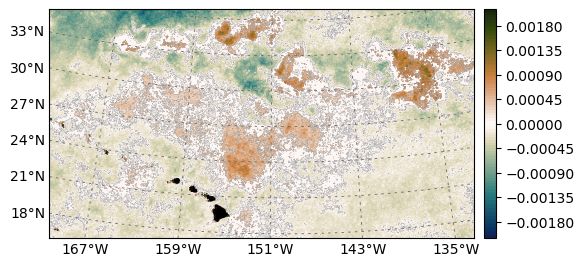

In [21]:
fig, ax1 = plt.subplots(1, 1, figsize=(6.6, 5.5))
m = Basemap(projection='lcc', resolution='l',
    llcrnrlat=16, urcrnrlat=35.5,
    llcrnrlon=-170, urcrnrlon=-130,
    lat_0=30, lon_0=-150,
    width=5.1E6, height=5E6)

x_map, y_map = np.meshgrid(sig_slopes.y, sig_slopes.x)
x, y = m(x_map, y_map)

# Main filled contour
contour = m.contourf(x, y, sig_slopes, cmap=cmocean.cm.tarn_r, levels=100, extend='neither', norm=divnorm)

# Contour line around significant regions
# Binary mask: 1 where significant, 0 where not
sig_binary = np.where(pvals <= 0.05, 1, 0).astype(float)
m.contour(x, y, sig_binary, levels=[0.5], colors='grey', linewidths=0.2, linestyle = "-", ax=ax1)

m.fillcontinents(color='black')
parallels = m.drawparallels(np.arange(18, 40, 3), labels=[1,0,0,0], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5), linewidth = 0.6)
meridians =  m.drawmeridians(np.arange(-175, -130, 8), labels=[0,0,0,1], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5),linewidth = 0.6)
m.drawcoastlines(color='black')

cbar = fig.colorbar(contour, shrink=0.54, pad=0.02)

# plt.title("Climate signal of summertime chlorophyl from 1997 to 2023 [$mg$ $m^{-3}$ $year^{-1}$]")
plt.savefig('../../figures/bloom_slope_chl_20260316.png', bbox_inches='tight', dpi=600)
plt.savefig('../../figures/bloom_slope_chl_20260316.pdf', bbox_inches='tight', dpi=600)
plt.show()